In [33]:
#Import libraries, load the dataset, and convert it into a DataFrame.

import pandas as pd
from datasets import load_dataset
import matplotlib.pyplot as plt
import seaborn as sns
import ast

dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Initial exploration of the dataset structure, shape, and missing values before any cleaning. 
# Lines commented out below were used for inspection and are kept for reference.

#df.head()
#df.tail()
#df.shape
#df.describe()
#df.info()
#df.isnull().sum()

# Data cleanup:
# - Convert job_posted_date from string to datetime.
# - Convert job_skills from a string representation of a list into an 
# actual Python list using ast.literal_eval, skipping NaN values.

df['job_posted_date'] = pd.to_datetime(df['job_posted_date'])
df['job_skills'] = df['job_skills'].apply(lambda skill_list: ast.literal_eval(skill_list) if pd.notna(skill_list) else skill_list)

In [34]:
df_US = df[df['job_country'] == 'United States'].dropna(subset='salary_year_avg')

job_titles = df_US['job_title_short'].value_counts().index[:6].tolist()

df_US_top6 = df_US[df_US['job_title_short'].isin(job_titles)]

job_order = df_US_top6.groupby('job_title_short')['salary_year_avg'].median().sort_values(ascending=False).index

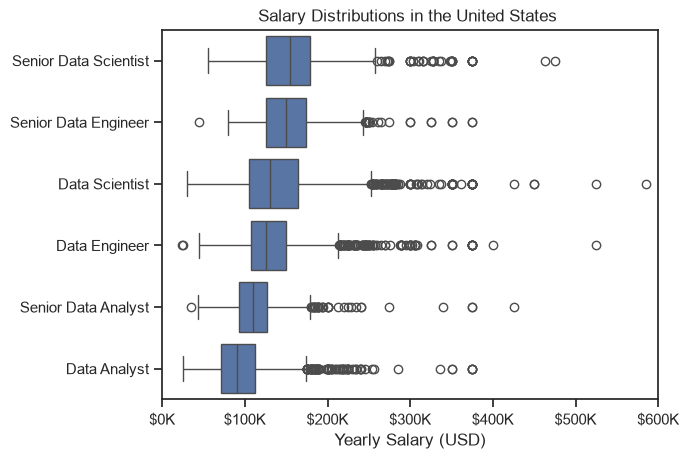

In [35]:
sns.boxplot(data=df_US_top6, x='salary_year_avg', y='job_title_short', order=job_order)
sns.set_theme(style='ticks')

plt.title('Salary Distributions in the United States ')
plt.xlabel('Yearly Salary (USD)')
plt.ylabel('')
plt.xlim(0, 600000)

ticks_x = plt.FuncFormatter(lambda x, pos: f'${int(x/1000)}K')
plt.gca().xaxis.set_major_formatter(ticks_x)
plt.show()